In [ ]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv")
df

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37244,jesus,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [ ]:
df.shape

(37249, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [ ]:
df['clean_comment'].isnull().sum()

np.int64(100)

In [ ]:
df.isnull().sum()

,0
clean_comment,100
category,0


In [ ]:
df['clean_comment'].isnull().sum()


np.int64(100)

In [ ]:
df.dropna(inplace=True)


In [ ]:
df.duplicated().sum()

np.int64(350)

In [ ]:
# Removing duplicates values in dataframe
df.drop_duplicates(inplace=True)

In [ ]:
df[(df['clean_comment'].str.strip() == '')]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [ ]:
df['clean_comment'] = df['clean_comment'].str.lower()


In [ ]:
# Identify comments containing URLs
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = df[df['clean_comment'].str.contains(url_pattern, regex=True)]

# Display the comments containing URLs
comments_with_urls.head()

# meaning of regex=True:

# “Treat the pattern as a rule (regex), not as literal text.”

# So for URL detection, you must use regex=True, otherwise it won’t understand [s]? or other regex symbols.

,clean_comment,category


### **EDA (Exploratory Data Analysis)**

<Axes: xlabel='category', ylabel='count'>

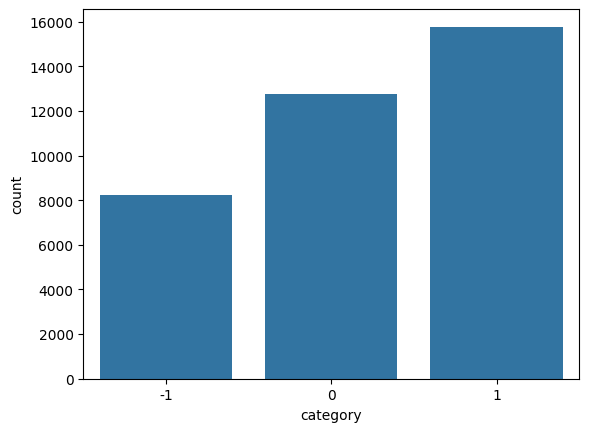

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data = df , x = 'category')

In [ ]:
df['category'].value_counts(normalize=True).mul(100).round(2)

,proportion
category,
1,42.86
0,34.72
-1,22.42


In [ ]:
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))

In [ ]:
df.sample(5)


,clean_comment,category,word_count
28041,wonder what exactly are the cyber warfare cap...,1,107
32429,buddha sathiyaa gaya hai,0,4
19081,surprising one its amazing how fraud this magn...,1,12
13279,lol ofcourse what else did you guys expect vot...,1,16
16955,add this real news fake news,-1,6


In [ ]:
df['word_count'].describe()

,word_count
count,36799.000000
mean,29.662627
std,56.787371
min,0.000000
25%,6.000000
50%,13.000000
75%,30.000000
max,1307.000000


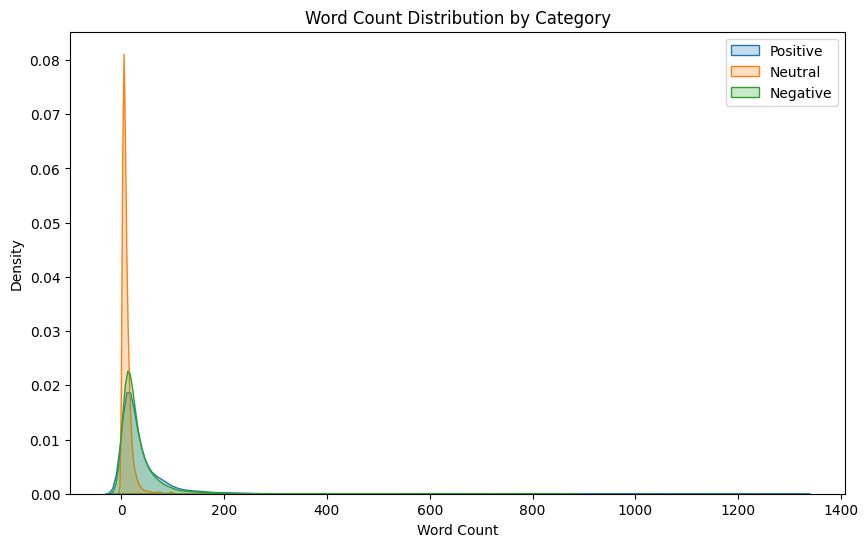

In [ ]:
from matplotlib import legend
# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot KDE for category 1
sns.kdeplot(df[df['category'] == 1]['word_count'], label='Positive', fill=True)

# Plot KDE for category 0
sns.kdeplot(df[df['category'] == 0]['word_count'], label='Neutral', fill=True)

# Plot KDE for category -1
sns.kdeplot(df[df['category'] == -1]['word_count'], label='Negative', fill=True)

# Add title and labels
plt.title('Word Count Distribution by Category')
plt.xlabel('Word Count')
plt.ylabel('Density')

# add legend
plt.legend()
# show the plot
plt.show()

* df[df['category'] == 1] → select only rows where category = 1

* ['word_count'] → take only the word count of those rows

* sns.kdeplot(..., fill=True) → plots a smooth density curve

* X-axis = word count

* Y-axis = density (how common each word count is)

* fill=True → fills the area under the curve for better visualization

* label='Positive' → gives a name for the legend

{'whiskers': [<matplotlib.lines.Line2D at 0x7a63dc31d6d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a63dc31dc70>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a63dc2ce630>],
 'medians': [<matplotlib.lines.Line2D at 0x7a63dc31e2d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a63dc31e5a0>],
 'means': []}

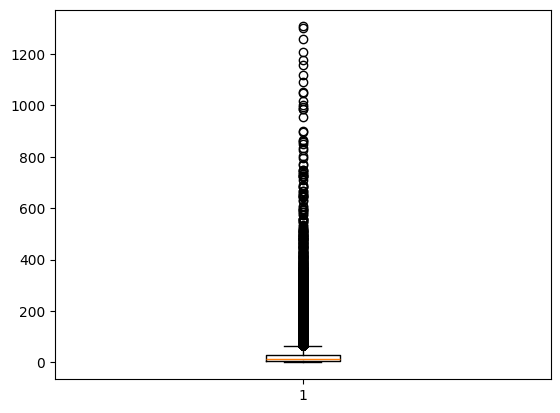

In [ ]:
plt.boxplot(df['word_count'])

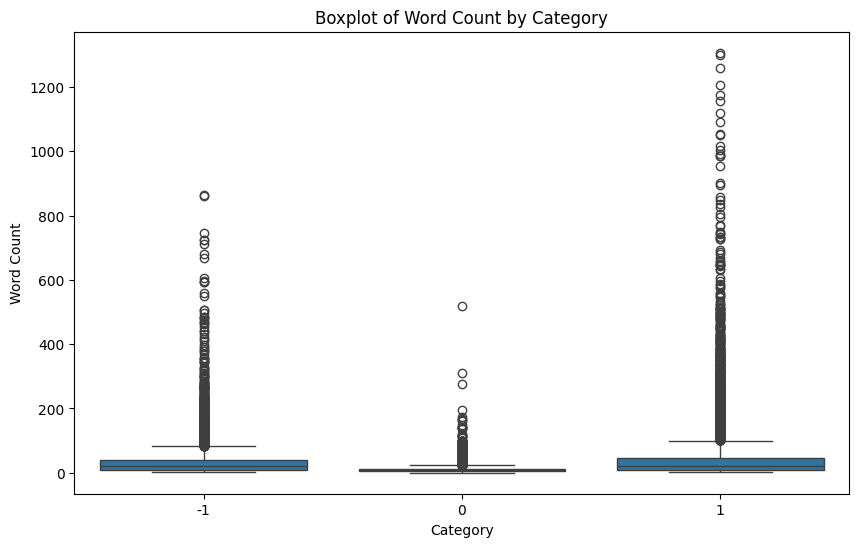

In [ ]:
# Create a boxplot for the 'wordcount' column categorized by 'category'
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='word_count')
plt.title('Boxplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

<Axes: xlabel='category', ylabel='word_count'>

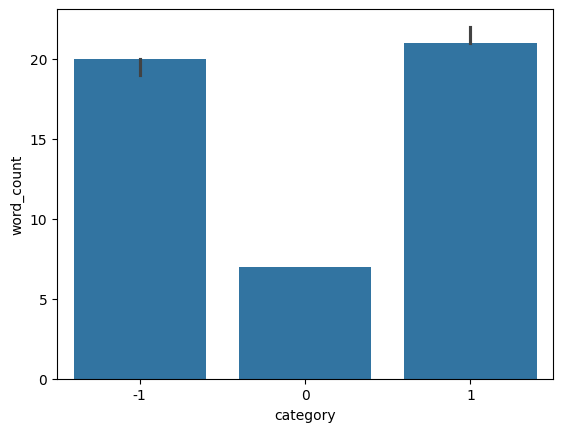

In [ ]:
# median word counts among sentiments
sns.barplot(df, x='category', y='word_count', estimator='median')

In [ ]:
import nltk


In [ ]:
from nltk.corpus import stopwords
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords

# Download NLTK stopwords if not already downloaded
nltk.download('stopwords')

# Define the list of English stopwords
stop_words = set(stopwords.words('english'))

# Create a new column 'num_stop_words' by counting the number of stopwords in each comment
df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words
8565,just when thought country was starting act pro...,-1,12,5
28932,think now makes sense video editing abhinanda...,-1,25,5
14131,based indian,0,2,0
33780,you have our respect series when ’ done half y...,-1,19,8
32628,cringe max this guy way cringier than trump sh...,0,9,2


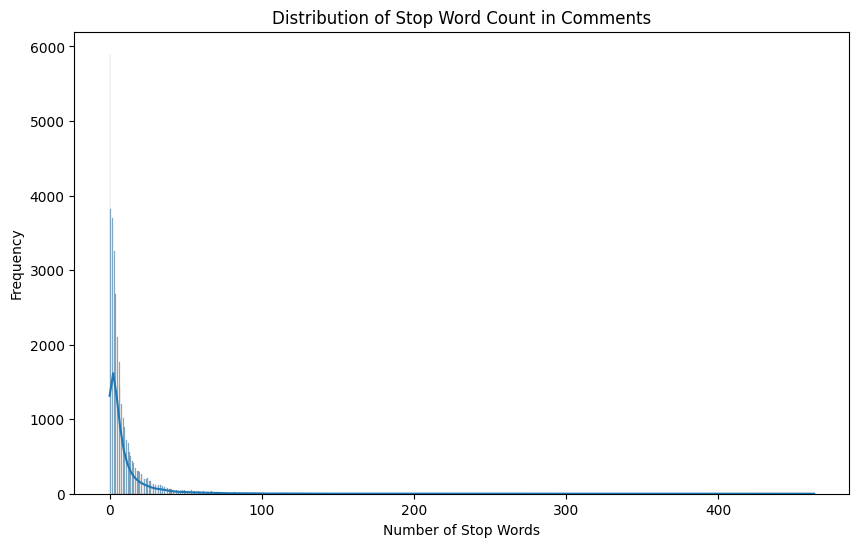

In [ ]:
# Create a distribution plot (displot) for the 'num_stop_words' column
plt.figure(figsize=(10, 6))
sns.histplot(df['num_stop_words'], kde=True)
plt.title('Distribution of Stop Word Count in Comments')
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')
plt.show()

/tmp/ipython-input-87103404.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')


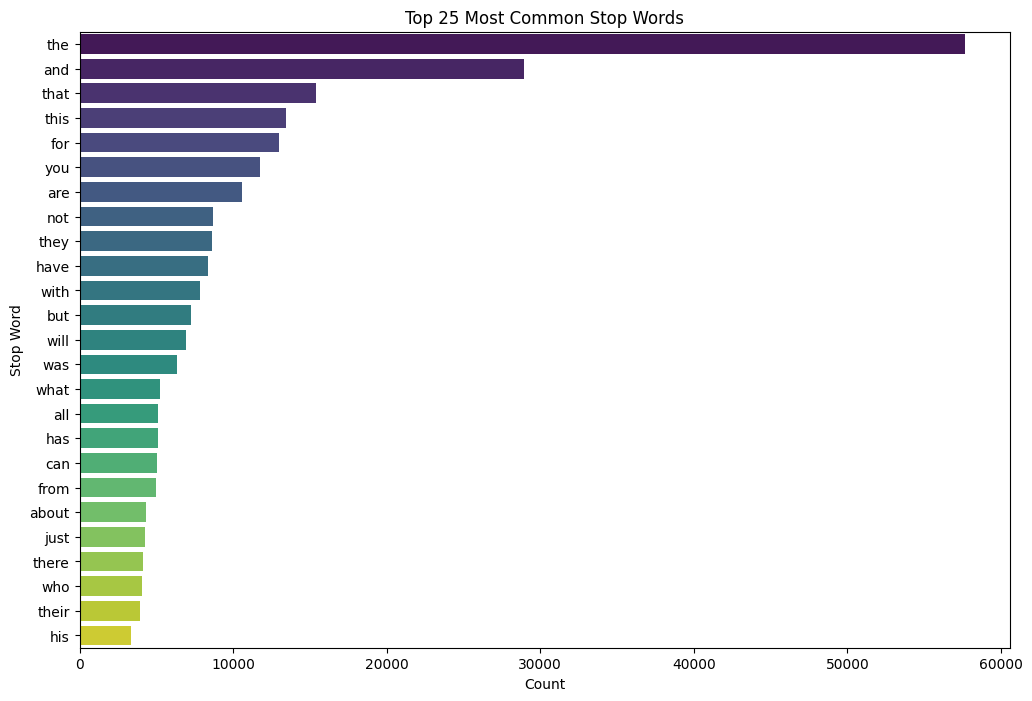

In [ ]:
# Create a frequency distribution of stop words in the 'clean_comment' column
from collections import Counter

# Extract all stop words from the comments using the previously defined 'common_stopwords'
all_stop_words = [word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]

# Count the most common stop words
most_common_stop_words = Counter(all_stop_words).most_common(25)

# Convert the most common stop words to a DataFrame for plotting
top_25_df = pd.DataFrame(most_common_stop_words, columns=['stop_word', 'count'])

# Create the barplot for the top 25 most common stop words
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Count')
plt.ylabel('Stop Word')
plt.show()

In [ ]:
from collections import Counter

# Combine all comments into one large string
all_text = ' '.join(df['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)

In [ ]:
char_frequency_df

,character,frequency
0,,1133435
12,e,666610
13,t,491287
2,a,481134
4,i,401388
...,...,...
323,ï,1
326,ഡ,1
338,ബ,1
1347,统,1


In [ ]:
# Remove non-English characters from the 'clean_comment' column
# Keeping only standard English letters, digits, and common punctuation
import re

df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x)))

In [ ]:
from nltk.corpus import stopwords

# Defining stop words but keeping essential ones for sentiment analysis
stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}

# Remove stop words from 'clean_comment' column, retaining essential ones
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)

In [ ]:
df.head(5)

,clean_comment,category,word_count,num_stop_words
0,family mormon never tried explain still stare ...,1,39,13
1,buddhism much lot compatible christianity espe...,1,196,59
2,seriously say thing first get complex explain ...,-1,86,40
3,learned want teach different focus goal not wr...,0,29,15
4,benefit may want read living buddha living chr...,1,112,45


In [ ]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

# Define the lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to the 'clean_comment_no_stopwords' column
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

df.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_comment,category,word_count,num_stop_words
0,family mormon never tried explain still stare ...,1,39,13
1,buddhism much lot compatible christianity espe...,1,196,59
2,seriously say thing first get complex explain ...,-1,86,40
3,learned want teach different focus goal not wr...,0,29,15
4,benefit may want read living buddha living chr...,1,112,45


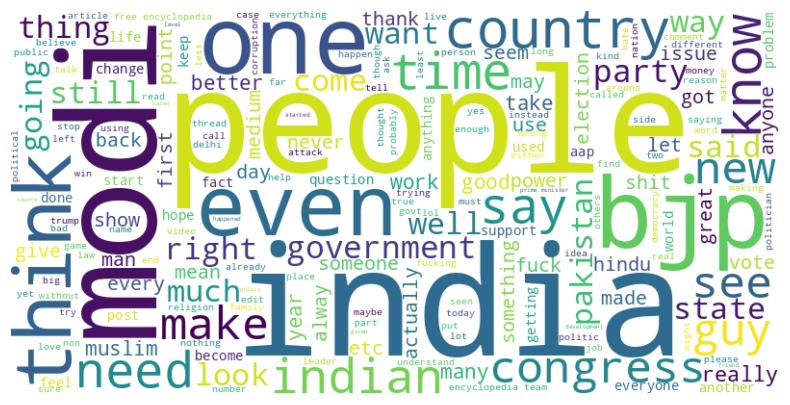

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df['clean_comment'])

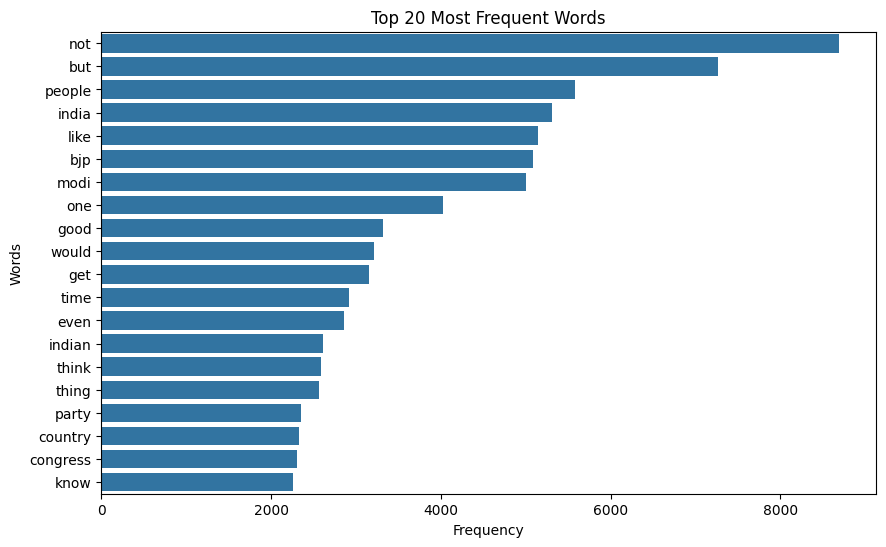

In [ ]:
def plot_top_n_words(df, n=20):
    """Plot the top N most frequent words in the dataset."""
    # Flatten all words in the content column
    words = ' '.join(df['clean_comment']).split()

    # Get the top N most common words
    counter = Counter(words)
    most_common_words = counter.most_common(n)

    # Split the words and their counts for plotting
    words, counts = zip(*most_common_words)

    # Plot the top N words
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

plot_top_n_words(df, n=20)

In [ ]:
from collections import Counter
Counter(["a","b","a","c","b","a"])
# Output → {'a':3, 'b':2, 'c':1}


Counter({'a': 3, 'b': 2, 'c': 1})

**E.g**

In [ ]:
dt = {
    "a" : ['happy is good thing','great method yar','bad think',],
    "b" : [1,1,0]
}
df2 = pd.DataFrame(dt)



In [ ]:
# df2['word_count'] = df2['a'].apply(lambda x: len(x.split()))
# df2

In [ ]:
# df2['a'].value_counts(normalize=True).mul(100).round(2)

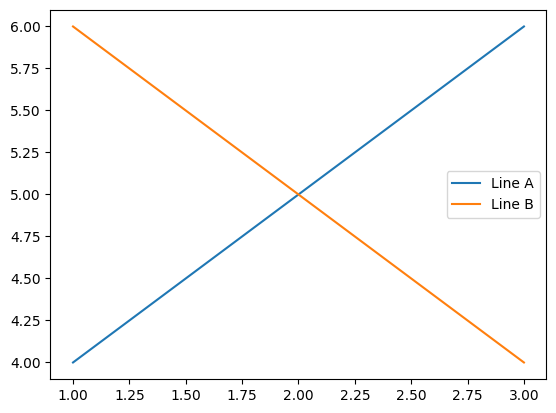

In [ ]:
import matplotlib.pyplot as plt

plt.plot([1,2,3], [4,5,6], label='Line A')
plt.plot([1,2,3], [6,5,4], label='Line B')

plt.legend()  # <-- this adds the legend
plt.show()
